## Encoder LLMs and Vector Embeddings

- Auto-regressive LLMs (Decoders) predicts a future token from the past by recurssively looking back to predict what the next tokens will be
- Auto-encoding LLMs (Encoders) produces output based on the full input. They only produce one output based on the context learned from the full input.

##### Applications of Encoders
- Sentiment Analysis/ Classification
- Used to calculate or generate "Vector Embeddings" representing an input as a list of number. i.e. vector

## Encoder LLMs and Vector Embeddings

- Auto-regressive LLMs (Decoders) predicts a future token from the past by recurssively looking back to predict what the next tokens will be
- Auto-encoding LLMs (Encoders) produces output based on the full input. They only produce one output based on the context learned from the full input.

##### Applications of Encoders
- Sentiment Analysis/ Classification
- Used to calculate or generate "Vector Embeddings" representing an input as a list of number. i.e. vector

## Standard RAG Archi
1. User asks a question
2. Questions hits a code that engages an encoder which converts question into a vector
3. User question alongside generated vector is stored in a vector database
4. Generated vector is used to find relevant context in the vector database that could match user's input (question)
5. Relevant context are returned with the most relevant ranked first. This returned relevant context comes with its natural language representation (alongside its vector)
6. User's Input + Retrieved relevant context hits an Auto-regressive LLM (a code) - which generates the answer back to the user

## Essential RAG Tools
- LangChain: Provides frameworks interfacing with LLMs. It also comes with a vector store called chroma.

There are other tools that can be used in connection with eachother instead of LangChain

In [1]:
import os
import numpy as np
import glob
from dotenv import load_dotenv
from pathlib import Path

import gradio as gr
from openai import OpenAI
import tiktoken

from langchain_openai import OpenAIEmbeddings
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

from sklearn.manifold import TSNE

import plotly.graph_objects as go

In [2]:
load_dotenv()
openai = OpenAI()

In [3]:
MODEL = "gpt-4.1-nano"

#### Divide Documents into CHUNKS

chunking is required as answers to user's question might just be a part of the document, and not necessarily returing all content in a document. There is no right or wrong to chunking techniques and this also part of the experimentation that comes with RAG.

#### Existing Documents

In [4]:
folder_list = glob.glob("knowledge-base/*")
folder_name = [Path(f).stem for f in folder_list]
file_list = glob.glob("knowledge-base/*/*.md", )
file_name = [Path(f).stem for f in file_list]

print(f'There are {len(folder_name)} folders')
print(f'There are {len(file_name)} files')

There are 4 folders
There are 76 files


In [5]:
entire_knowledge_base = ''

for file in file_list:
    with open(file, 'r', encoding='utf-8') as f:
        entire_knowledge_base += f.read()
        entire_knowledge_base += "\n\n"

print(f"Total characters in knowledge base: {len(entire_knowledge_base):,}")

Total characters in knowledge base: 304,434


##### create chunks

In [6]:
### create chunks without langchain
def create_chunks(entire_knowledge_base, 
                  chunk_size = 1000, 
                  chunk_overlap = 100):
    chunks = []
    for step in range(chunk_size, len(entire_knowledge_base) + chunk_size, chunk_size):
        if not chunks:
            chunk = entire_knowledge_base[:step]
            chunks.append(chunk)
        else:
            chunk = entire_knowledge_base[step - (chunk_size + chunk_overlap): step]
            chunks.append(chunk)
    
    print(f"Number of chunks: {len(chunks)} ")
    return chunks

In [7]:
chunks_ = create_chunks(entire_knowledge_base, 
                  chunk_size = 1000, 
                  chunk_overlap = 100)

Number of chunks: 305 


In [8]:
chunks_[0]

'# About Insurellm\n\nInsurellm was founded by Avery Lancaster in 2015 as an insurance tech startup designed to disrupt an industry in need of innovative products. Its first product was Markellm, the marketplace connecting consumers with insurance providers.\n\nThe company experienced rapid growth in its first five years, expanding its product portfolio to include Carllm (auto insurance portal), Homellm (home insurance portal), and Rellm (enterprise reinsurance platform). By 2020, Insurellm had reached a peak of 200 employees with 12 offices across the US.\n\nHowever, the company underwent a strategic restructuring in 2022-2023 to focus on profitability and sustainable growth. This included consolidating office locations, implementing a remote-first strategy, and streamlining operations. As of 2025, Insurellm operates with a lean, highly efficient team of 32 employees who have built a portfolio of 32 active contracts spanning all eight product lines. The company maintains its San Franc

In [9]:
chunks_[1]

' of 32 active contracts spanning all eight product lines. The company maintains its San Francisco headquarters along with small satellite offices in key markets including New York, Austin, Chicago, and Denver.\n\nSince the restructuring, Insurellm has continued to innovate, expanding its product suite to eight comprehensive platforms. The company added Lifellm (life insurance), Healthllm (health insurance), Bizllm (commercial insurance), and Claimllm (claims processing) to serve the full spectrum of insurance needs. This strategic expansion has been highly successful, with strong adoption across all new products:\n\n- **Bizllm** quickly gained traction with 7 commercial insurance contracts, including regional carriers and national commercial groups\n- **Claimllm** signed 7 contracts ranging from independent adjusting firms to enterprise claims networks\n- **Lifellm** secured 6 life insurance clients from small regional providers to major national carriers\n- **Healthllm** won 6 health

In [10]:
chunks_[302]

'ent Module\nThe comprehensive risk assessment module within Rellm allows insurers to evaluate risk profiles accurately. By leveraging historical data and advanced modeling techniques, Rellm provides a clear picture of potential liabilities and expected outcomes.\n\n### Customizable Dashboard\nRellm features a customizable dashboard that presents key metrics and performance indicators in an intuitive interface. Users can tailor their view to focus on what matters most to their business, enhancing user experience and productivity.\n\n### Regulatory Compliance Tools\nRellm includes built-in compliance tracking features to help organizations meet local and international regulatory standards. This ensures that reinsurance practices remain transparent and accountable.\n\n### Client and Broker Portals\nRellm offers dedicated portals for both clients and brokers, facilitating real-time communication and documentation sharing. This strengthens partnerships and drives operational excellence acr

In [11]:
chunks_[303]

'rd.\n\n## Pricing\n\nInsurellm offers flexible pricing plans for Rellm to cater to various business needs:\n\n- **Basic Plan**: $5,000/month\n  - Includes access to core features and standard integrations.\n  \n- **Professional Plan**: $10,000/month\n  - Includes all features, advanced integrations, and priority customer support.\n  \n- **Enterprise Plan**: Custom pricing\n  - Tailored solutions with personalized features, extensive integrations, and dedicated account management.\n\nJoin the growing number of organizations leveraging Rellm to enhance their reinsurance processes while driving profitability and compliance. \n\n## 2025-2026 Roadmap\n\nAt Insurellm, we are committed to the continuous improvement of Rellm. Our roadmap for 2025-2026 includes:\n\n- **Q3 2025**: \n  - Launch of the Rellm Mobile App for on-the-go insights and management.\n  - Introduction of augmented reality (AR) features for interactive risk assessments.\n\n- **Q1 2026**: \n  - Deployment of advanced machine

In [12]:
chunks_[304]

'ore accurate risk predictions.\n  - Expansion of integration capabilities to support emerging technologies in the insurance sector.\n\n- **Q3 2026**: \n  - Release of a community platform for Rellm users to exchange insights, tips, and best practices.\n  - Launch of Rellm 2.0, featuring enhanced user interface and premium features based on user feedback.\n\nExperience the future of reinsurance with Rellm, where innovation meets reliability. Let Insurellm help you navigate the complexities of the reinsurance market smarter and faster.\n\n'

#### Check Number of Tokens in Knowledge base

In [13]:
# How many tokens in all the documents ?
encoding=tiktoken.encoding_for_model(MODEL)
token = encoding.encode(entire_knowledge_base)
# show first 10
print(token[:10])
print(f"Total tokens for {MODEL}: {len(token):,}")

[2, 12958, 10608, 627, 680, 76, 279, 13345, 627, 680]
Total tokens for gpt-4.1-nano: 63,555


In [14]:
# NOTE: The entire knowledge base could fit into the context window of the model, but we won't feed it in
# RAG is meant to work at scale. We chunk the knowledge base to ensure scalability.

### Use LangChain to Load Documents

In [15]:
folders = glob.glob("knowledge-base/*")

documents = []
for folder in folders:
    doc_type = os.path.basename(folder)
    loader = DirectoryLoader(folder, "**/*.md", loader_cls=TextLoader, loader_kwargs={"encoding":"utf-8"})
    folder_docs = loader.load()
    for doc in folder_docs:
        doc.metadata["doc_type"] = doc_type
        documents.append(doc)

print(f"Loaded {len(documents)} documents")

Loaded 76 documents


In [16]:
documents[0]

Document(metadata={'source': 'knowledge-base\\company\\about.md', 'doc_type': 'company'}, page_content="# About Insurellm\n\nInsurellm was founded by Avery Lancaster in 2015 as an insurance tech startup designed to disrupt an industry in need of innovative products. Its first product was Markellm, the marketplace connecting consumers with insurance providers.\n\nThe company experienced rapid growth in its first five years, expanding its product portfolio to include Carllm (auto insurance portal), Homellm (home insurance portal), and Rellm (enterprise reinsurance platform). By 2020, Insurellm had reached a peak of 200 employees with 12 offices across the US.\n\nHowever, the company underwent a strategic restructuring in 2022-2023 to focus on profitability and sustainable growth. This included consolidating office locations, implementing a remote-first strategy, and streamlining operations. As of 2025, Insurellm operates with a lean, highly efficient team of 32 employees who have built a

### Use LangChain to create Chunks

There is no right or wrong to chunking (i.e. it is experimental). However, Langchain has provided functions for different types of chunking methods. Look here : `langchain_text_splitters` for more.

Common standards to creating chunks:
- There should a chunk size: number of words or character in a chunk.
- chunk overlap: How many words would intersect (overlap) between successive chunks.

Reason for chunk overlap is to ensure we get relevant context based on users input. For instance: The begining of a relevant context could be the end of a chunk. However, overlap ensures that we get rich context from a chunk by ensuring the next chunk contains the relevant information needed.

In [17]:
# Divide into chunks using RecursiveCharacterTextSpliter
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)

# we pass in the documents created using langchain `DirectoryLoader`
chunks = text_splitter.split_documents(documents)

print(f"Divided into {len(chunks)} chunks")
print(f"first chunk: \n\n {chunks[0]}")

Divided into 413 chunks
first chunk: 

 page_content='# About Insurellm

Insurellm was founded by Avery Lancaster in 2015 as an insurance tech startup designed to disrupt an industry in need of innovative products. Its first product was Markellm, the marketplace connecting consumers with insurance providers.

The company experienced rapid growth in its first five years, expanding its product portfolio to include Carllm (auto insurance portal), Homellm (home insurance portal), and Rellm (enterprise reinsurance platform). By 2020, Insurellm had reached a peak of 200 employees with 12 offices across the US.' metadata={'source': 'knowledge-base\\company\\about.md', 'doc_type': 'company'}


In [18]:
chunks[100]

Document(metadata={'source': 'knowledge-base\\contracts\\Contract with GlobalRe Partners for Rellm.md', 'doc_type': 'contracts'}, page_content='13. **Climate Risk Analytics:** Forward-looking climate modeling:\n    - IPCC climate scenario analysis (RCP 2.6, 4.5, 8.5)\n    - Transition risk assessment\n    - Physical risk modeling for perils (hurricane, wildfire, flood, drought)\n    - Sea level rise impact analysis\n    - Temperature trend incorporation\n    - Climate-adjusted pricing recommendations\n    - Stranded asset identification\n    - Green reinsurance opportunities\n\n---\n\n## Support\n\nInsurellm commits to comprehensive Enterprise-level support for GlobalRe Partners:\n\n1. **Dedicated Success Team:**\n   - Executive sponsor (CEO-level) with quarterly strategic reviews\n   - Dedicated Senior Vice President of Customer Success with bi-weekly engagement\n   - Technical Account Manager for platform optimization\n   - Solutions Architect team (2 FTE) for strategic initiatives\n

### Vectorizing Chunks and Storing Them

In terms of storage, any vector database should be fine. However, particular concern should be on the type of `Encoder` model used to vectorize (create embedding) these chunks.

#### Make vectors using HuggingFace Embedding Model and store to Chroma

In [19]:
# vector db name
db_name ="vector_db"

In [20]:
# pick an embedding model
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
# embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

if os.path.exists(db_name):
    Chroma(persist_directory=db_name, embedding_function=embeddings).delete_collection()

vectorstore = Chroma.from_documents(documents=chunks, embedding=embeddings, persist_directory=db_name)
print(f"vectorstore created with {vectorstore._collection.count()} documents")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

vectorstore created with 413 documents


In [21]:
### sense checking created vector
collection = vectorstore._collection
count = collection.count()

# get a sample (limit=1) from the vector store, and just return the embedding
sample_embedding = collection.get(limit=1, include=["embeddings"])

In [22]:
sample_embedding['embeddings'].shape

(1, 384)

#### visualise 

Data or vectors of multi-dimensions (3-D or more) can't be viewed by humans so we reduce the dimension to 2-D (human-friendly) using T-SNE

In [23]:
result = vectorstore._collection.get(include=["embeddings", "documents", "metadatas"], )

In [24]:
vectors = np.array(result["embeddings"])
documents = result["documents"]
metadatas = result["metadatas"]

doc_types= [metadata["doc_type"] for metadata in metadatas]


### 2D plot

In [25]:
# dimensionality reduction using t-sne
tsne = TSNE(n_components=2, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

In [26]:
color_map = []
for t in doc_types:
    colors = ["blue", "green", "red", "orange"]
    idx = ["products", "employees", "contracts","company"].index(t) 
    color_map.append(colors[idx])

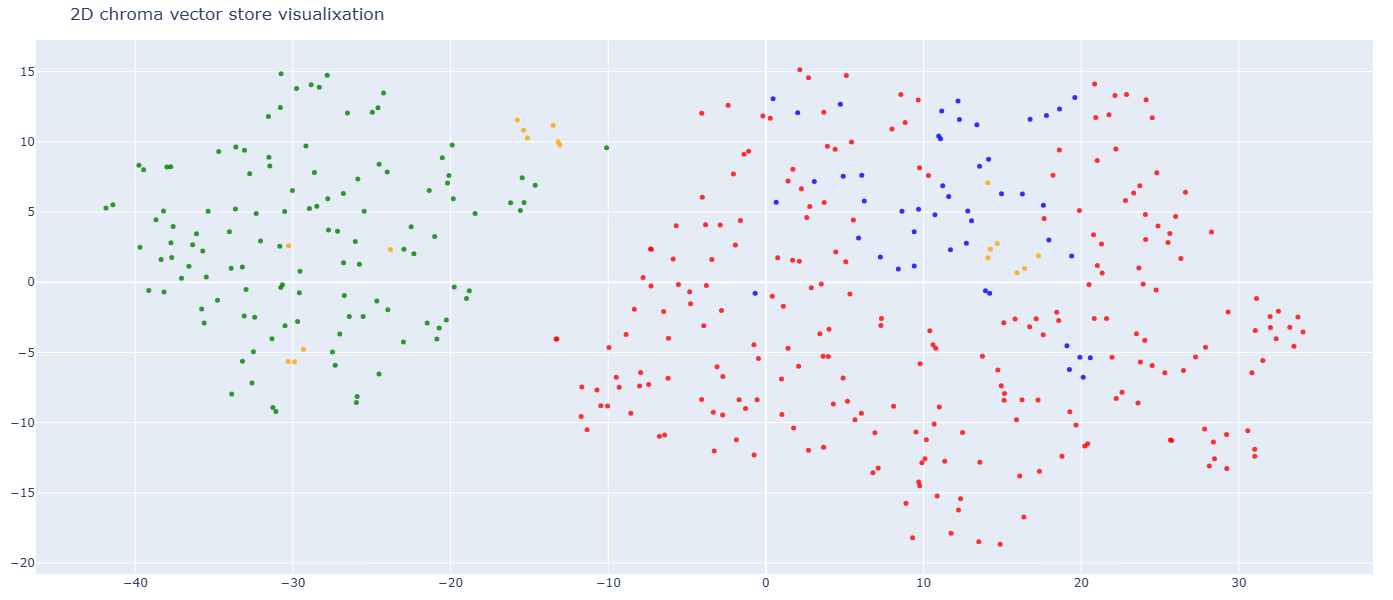

In [27]:
# create the 2D scatter plot
fig = go.Figure(data=go.Scatter(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    mode="markers",
    marker=dict(size=5, color=color_map, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t,d in zip(doc_types, documents)],
    hoverinfo='text'
))

fig.update_layout(title="2D chroma vector store visualixation",
                  scene=dict(xaxis_title="x", yaxis_title="y"),
                  width=800,
                  height=600,
                  margin=dict(r=20, b=10, l=10, t=40)

)

fig.show()

### 3D Plot

In [28]:
# dimensionality reduction using t-sne
tsne = TSNE(n_components=3, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

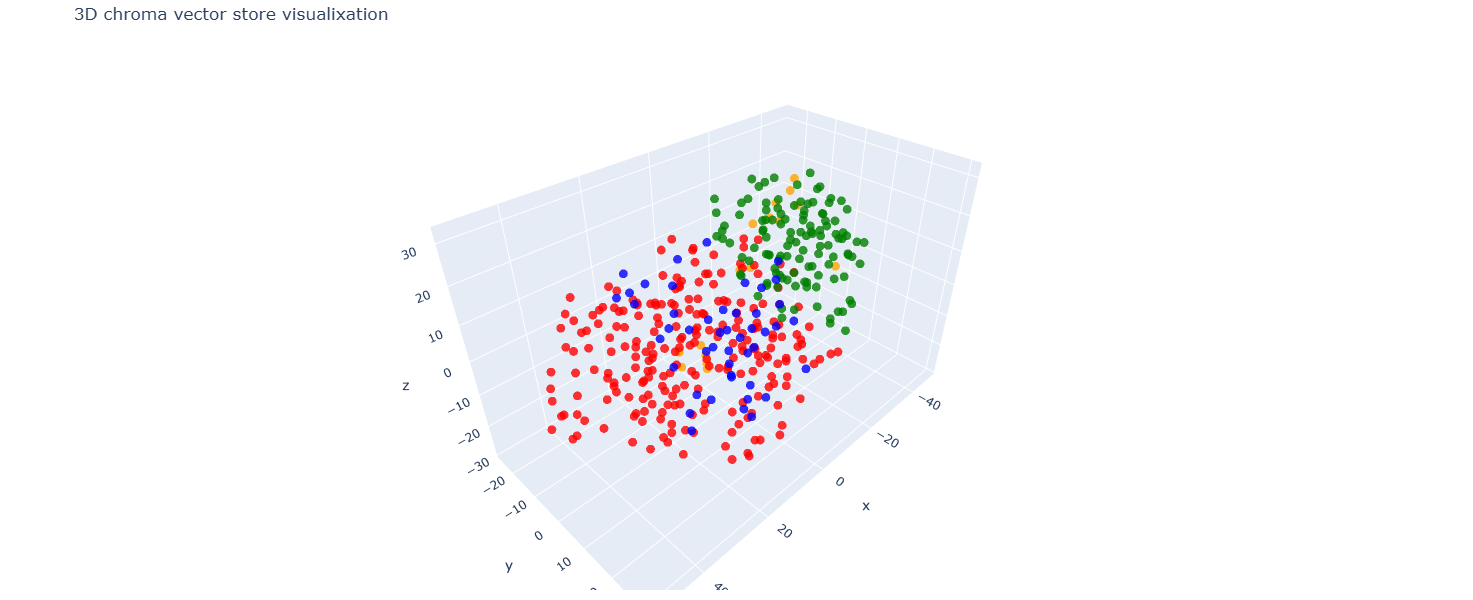

In [29]:
# create the 3D scatter plot
fig = go.Figure(data=go.Scatter3d(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    z=reduced_vectors[:, 2],
    mode="markers",
    marker=dict(size=5, color=color_map, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t,d in zip(doc_types, documents)],
    hoverinfo='text'
))

fig.update_layout(title="3D chroma vector store visualixation",
                  scene=dict(xaxis_title="x", yaxis_title="y"),
                  width=800,
                  height=600,
                  margin=dict(r=20, b=10, l=10, t=40)

)

fig.show()

Essentially this plots especially the 3D plot help to investigate how the embedding model has group similar items in clusters. Which could also inform us to either stick with an embedding model or change it if we think its not doing a good job.

### Using OpenAI Embedding

In [30]:
# pick an embedding model
# embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

if os.path.exists(db_name):
    Chroma(persist_directory=db_name, embedding_function=embeddings).delete_collection()

vectorstore = Chroma.from_documents(documents=chunks, embedding=embeddings, persist_directory=db_name)
print(f"vectorstore created with {vectorstore._collection.count()} documents")

vectorstore created with 413 documents


In [31]:
### sense checking created vector

collection = vectorstore._collection
count = collection.count()

# get a sample (limit=1) from the vector store, and just return the embedding
sample_embedding = collection.get(limit=1, include=["embeddings"])

In [32]:
sample_embedding['embeddings'].shape

(1, 1536)

#### visualise 

Data or vectors of multi-dimensions (3-D or more) can't be viewed by humans so we reduce the dimension to 2-D (human-friendly) using T-SNE

In [33]:
result = vectorstore._collection.get(include=["embeddings", "documents", "metadatas"], )

In [34]:
vectors = np.array(result["embeddings"])
documents = result["documents"]
metadatas = result["metadatas"]

doc_types= [metadata["doc_type"] for metadata in metadatas]


### 2D plot

In [35]:
# dimensionality reduction using t-sne
tsne = TSNE(n_components=2, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

In [36]:
color_map = []
for t in doc_types:
    colors = ["blue", "green", "red", "orange"]
    idx = ["products", "employees", "contracts","company"].index(t) 
    color_map.append(colors[idx])

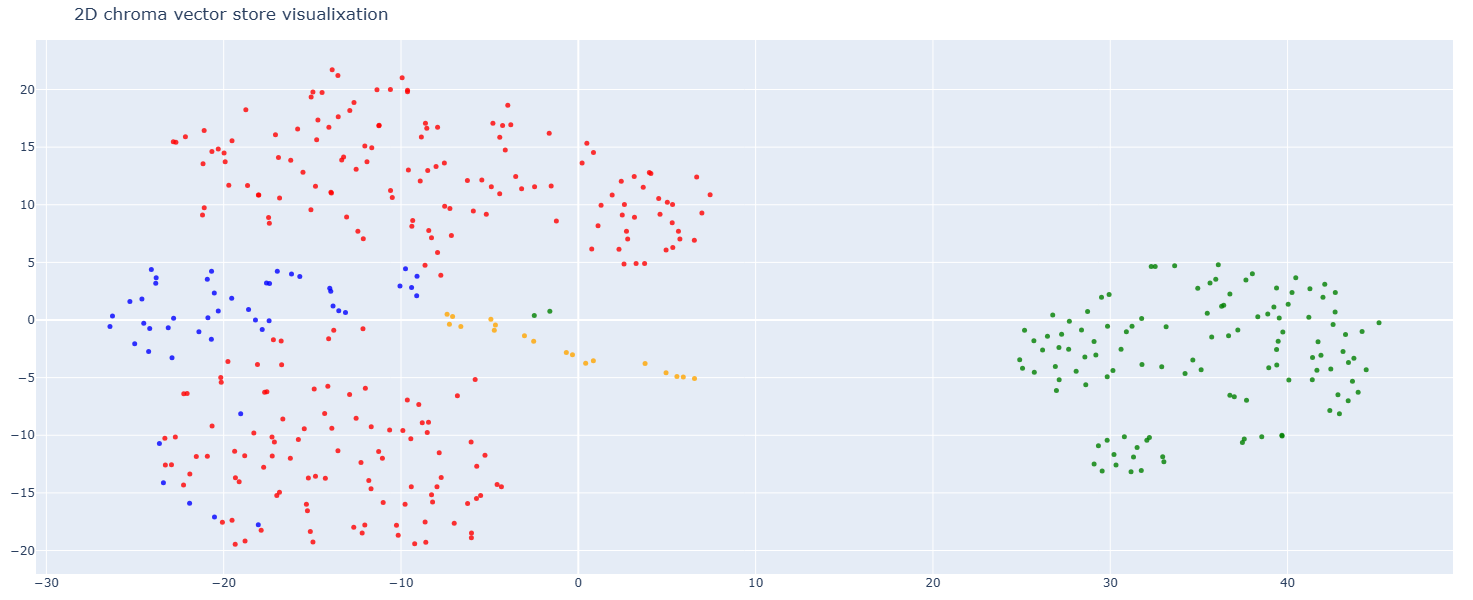

In [37]:
# create the 2D scatter plot
fig = go.Figure(data=go.Scatter(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    mode="markers",
    marker=dict(size=5, color=color_map, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t,d in zip(doc_types, documents)],
    hoverinfo='text'
))

fig.update_layout(title="2D chroma vector store visualixation",
                  scene=dict(xaxis_title="x", yaxis_title="y"),
                  width=800,
                  height=600,
                  margin=dict(r=20, b=10, l=10, t=40)

)

fig.show()

### 3D Plot

In [38]:
# dimensionality reduction using t-sne
tsne = TSNE(n_components=3, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

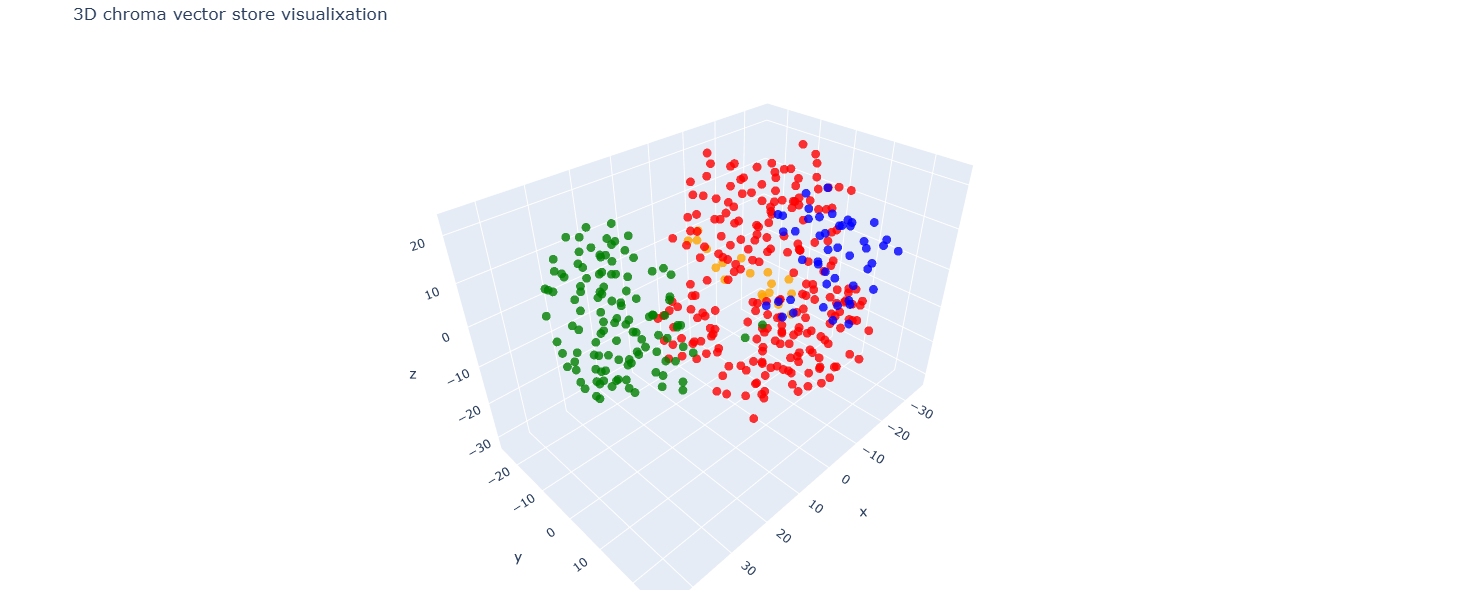

In [39]:
# create the 3D scatter plot
fig = go.Figure(data=go.Scatter3d(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    z=reduced_vectors[:, 2],
    mode="markers",
    marker=dict(size=5, color=color_map, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t,d in zip(doc_types, documents)],
    hoverinfo='text'
))

fig.update_layout(title="3D chroma vector store visualixation",
                  scene=dict(xaxis_title="x", yaxis_title="y"),
                  width=800,
                  height=600,
                  margin=dict(r=20, b=10, l=10, t=40)

)

fig.show()

The OpenAI embedding, although small was able to seprate the documents better

### Try Large OpenAI Embedding

In [40]:
# pick an embedding model
# embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

if os.path.exists(db_name):
    Chroma(persist_directory=db_name, embedding_function=embeddings).delete_collection()

vectorstore = Chroma.from_documents(documents=chunks, embedding=embeddings, persist_directory=db_name)
print(f"vectorstore created with {vectorstore._collection.count()} documents")

vectorstore created with 413 documents


In [41]:
### sense checking created vector

collection = vectorstore._collection
count = collection.count()

# get a sample (limit=1) from the vector store, and just return the embedding
sample_embedding = collection.get(limit=1, include=["embeddings"])

In [42]:
sample_embedding['embeddings'].shape

(1, 3072)

#### visualise 

Data or vectors of multi-dimensions (3-D or more) can't be viewed by humans so we reduce the dimension to 2-D (human-friendly) using T-SNE

In [43]:
result = vectorstore._collection.get(include=["embeddings", "documents", "metadatas"], )

In [44]:
vectors = np.array(result["embeddings"])
documents = result["documents"]
metadatas = result["metadatas"]

doc_types= [metadata["doc_type"] for metadata in metadatas]


### 2D plot

In [45]:
# dimensionality reduction using t-sne
tsne = TSNE(n_components=2, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

In [46]:
color_map = []
for t in doc_types:
    colors = ["blue", "green", "red", "orange"]
    idx = ["products", "employees", "contracts","company"].index(t) 
    color_map.append(colors[idx])

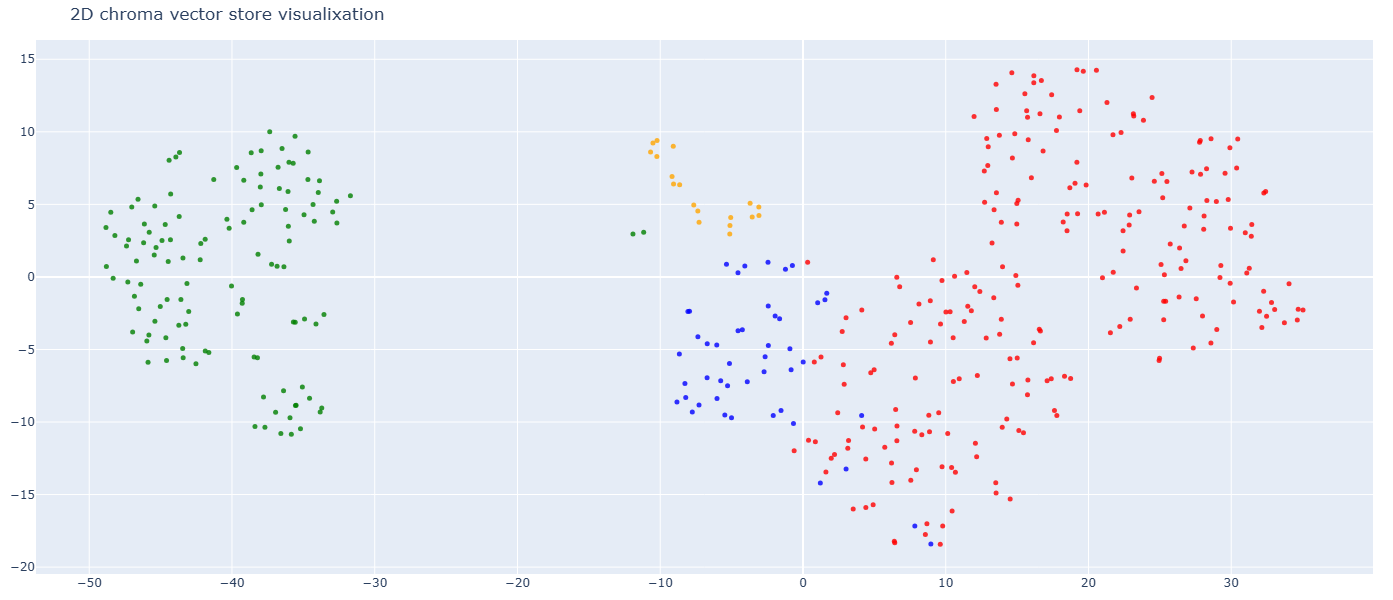

In [47]:
# create the 2D scatter plot
fig = go.Figure(data=go.Scatter(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    mode="markers",
    marker=dict(size=5, color=color_map, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t,d in zip(doc_types, documents)],
    hoverinfo='text'
))

fig.update_layout(title="2D chroma vector store visualixation",
                  scene=dict(xaxis_title="x", yaxis_title="y"),
                  width=800,
                  height=600,
                  margin=dict(r=20, b=10, l=10, t=40)

)

fig.show()

### 3D Plot

In [48]:
# dimensionality reduction using t-sne
tsne = TSNE(n_components=3, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

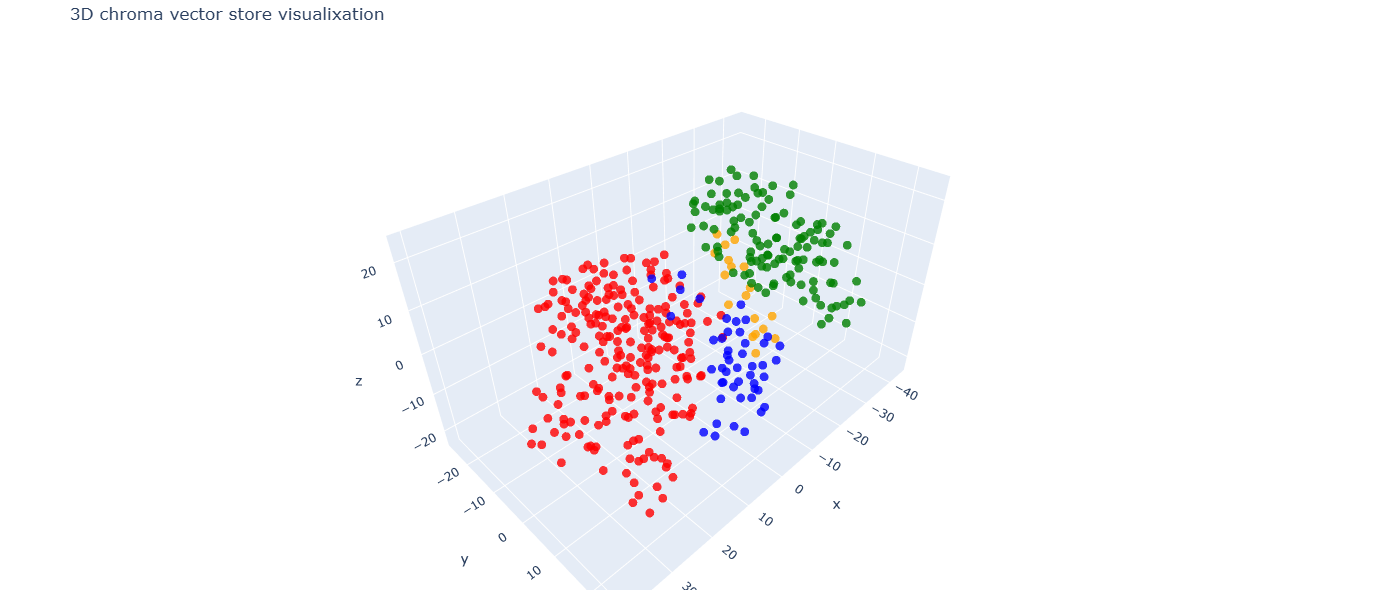

In [49]:
# create the 3D scatter plot
fig = go.Figure(data=go.Scatter3d(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    z=reduced_vectors[:, 2],
    mode="markers",
    marker=dict(size=5, color=color_map, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t,d in zip(doc_types, documents)],
    hoverinfo='text'
))

fig.update_layout(title="3D chroma vector store visualixation",
                  scene=dict(xaxis_title="x", yaxis_title="y"),
                  width=800,
                  height=600,
                  margin=dict(r=20, b=10, l=10, t=40)

)

fig.show()

In [50]:
SYSTEM_PREFIX =  """
You represent insurellm, the Insurance Tech Company.
You are an expert in answering questions about Insurellm; its employees and its products.
You are provided with additional context that might be relevant to the user's questions.
Give brief, accurate answers. If you don't know the answer, say so.

Relevant Context:
"""

In [51]:
def chat(message, history):
    system_message= SYSTEM_PREFIX + get_additional_context(message)
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages)
    return response.choices[0].message.content